# Lab 4 — Assignment


**Based on:** Lab-4-b (Bernoulli, Binomial, Poisson, Normal, Uniform)


---

### Instructions

1. Run the **Setup** cell first. Do not modify it.
2. There are **10 questions** — two on each distribution. Attempt **all** of them.
3. Every question has three parts:
   - **(a)** and **(b)** — work these out **by hand** and type your working in the *Written answer* cell.
   - **(c)** — write **Python code** in the blank code cell provided and produce the plot asked for.
4. Use `DISCRETE_COLOR` for discrete plots (bars) and `CONTINUOUS_COLOR` for continuous plots (curves).
5. Every plot must have an **x-label, y-label and a title**. Marks are deducted for unlabelled plots.
6. Round all probabilities to **4 decimal places**.
7. Save the notebook with all outputs visible before submitting.

### Marks distribution

| Section | Questions | Marks each | Total |
|---|---|---|---|
| A — Bernoulli | Q1, Q2 | 5 | 10 |
| B — Binomial | Q3, Q4 | 5 | 10 |
| C — Poisson | Q5, Q6 | 5 | 10 |
| D — Normal | Q7, Q8 | 5 | 10 |
| E — Uniform | Q9, Q10 | 5 | 10 |
| | | **Total** | **50** |

### Quick reference — which function do I need?

| Task | `scipy.stats` call |
|---|---|
| $P(X = k)$, discrete | `.pmf(k, ...)` |
| $f(x)$, continuous | `.pdf(x, ...)` |
| $P(X \le x)$ | `.cdf(x, ...)` |
| $P(X > x)$ | `.sf(x, ...)` |
| Value with given $P(X \le x)$ | `.ppf(prob, ...)` |
| Mean / variance | `.mean(...)`, `.var(...)` |
| Random samples | `.rvs(..., size=n, random_state=seed)` |

---

> **Completion note:** The uploaded file contains prompts for Q1–Q3 and Q5–Q9. The Q4 and Q10 prompts are absent from the source file; Q4's orphaned answer placeholder is documented below rather than inventing a question.


## Setup
Run this cell first — do not change it.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp, sqrt

DISCRETE_COLOR = "#0E9F9A"     # teal   -> discrete distributions
CONTINUOUS_COLOR = "#E4572E"   # orange -> continuous distributions
HIGHLIGHT_COLOR = "#F4A261"    # use this to highlight a bar or a shaded area

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete — you are ready to start.")

Setup complete — you are ready to start.


---
# Part A — Bernoulli distribution
*Recall:* $P(X=x) = p^x(1-p)^{1-x}$ for $x \in \{0,1\}$, $\;E[X]=p$, $\;Var(X)=p(1-p)$.

## Q1. The library gate scanner 

> 📚 The RFID gate at the college library reads a student's ID card correctly on the **first tap 92%** of the time. One student taps her card once.
>
> Let $X = 1$ if the card is read on the first tap, and $X = 0$ if it is not.
>
> **(a)** State the value of $p$ and find $P(X=1)$ and $P(X=0)$.
> **(b)** Find the mean and the variance of $X$, showing the substitution into the formulas.
> **(c)** Write Python code that:
> - builds the PMF of $X$ using `stats.bernoulli.pmf`,
> - draws a **bar chart** of the distribution in `DISCRETE_COLOR` with the ticks labelled `"Not read (0)"` and `"Read (1)"`,
> - writes the probability value on top of each bar,
> - prints the mean and the variance obtained from `scipy`, and checks that they match your hand answers in (b).

#### ✍️ Written answer (a) and (b) — *completed*

**(a)** This is a Bernoulli trial with \(p=0.92\). Therefore,
\[
P(X=1)=p=0.92,\qquad P(X=0)=1-p=1-0.92=0.08.
\]

**(b)**
\[
E[X]=p=0.92,
\qquad Var(X)=p(1-p)=0.92(0.08)=0.0736.
\]


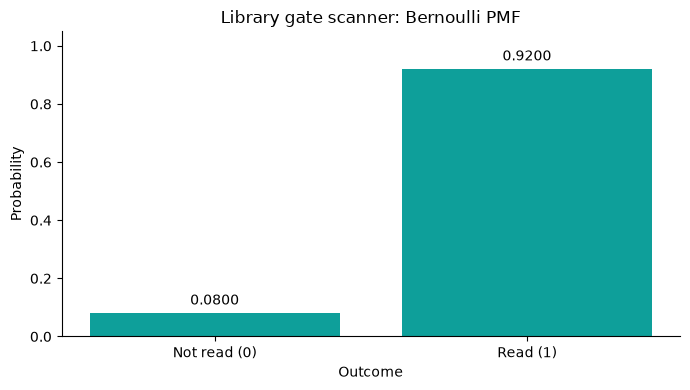

Mean from scipy: 0.9200 (hand answer: 0.9200; match=True)
Variance from scipy: 0.0736 (hand answer: 0.0736; match=True)


In [11]:
# Q1: Bernoulli PMF
p = 0.92
x = np.array([0, 1])
pmf = stats.bernoulli.pmf(x, p)

fig, ax = plt.subplots()
bars = ax.bar(x, pmf, color=DISCRETE_COLOR)
ax.set_xticks(x, ["Not read (0)", "Read (1)"])
ax.set_xlabel("Outcome")
ax.set_ylabel("Probability")
ax.set_title("Library gate scanner: Bernoulli PMF")
ax.set_ylim(0, 1.05)
for bar, value in zip(bars, pmf):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.03, f"{value:.4f}", ha="center")
plt.tight_layout()
plt.show()

mean_scipy = stats.bernoulli.mean(p)
var_scipy = stats.bernoulli.var(p)
print(f"Mean from scipy: {mean_scipy:.4f} (hand answer: {p:.4f}; match={np.isclose(mean_scipy, p)})")
print(f"Variance from scipy: {var_scipy:.4f} (hand answer: {p*(1-p):.4f}; match={np.isclose(var_scipy, p*(1-p))})")

## Q2. Estimating $p$ from attendance data &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 👆 A biometric attendance device records whether a student's fingerprint is accepted on the **first attempt**. Over one semester the device logged **2,000 scans**, of which **1,740** were accepted on the first attempt. Treat one scan as a single Bernoulli trial with $X=1$ for *accepted*.
>
> **(a)** Estimate $p$ from the data and write down the full PMF $P(X=x)$ with the estimated value substituted in.
> **(b)** Find the mean and variance. Then answer: for what value of $p$ would the variance of a Bernoulli variable be the **largest possible**, and what is that largest value? Justify your answer using the formula $Var(X)=p(1-p)$.
> **(c)** Write Python code that:
> - simulates 2,000 Bernoulli trials with your estimated $p$ using `stats.bernoulli.rvs(..., random_state=42)`,
> - prints the **simulated proportion** of successes next to the theoretical $p$,
> - plots the **theoretical PMF and the simulated relative frequencies side by side** as grouped bars with a legend,
> - plots $Var(X)=p(1-p)$ against $p$ for $p$ from 0 to 1 in a **second figure**, and marks the maximum point with a marker and an annotation.

#### ✍️ Written answer (a) and (b) — *completed*

**(a)** The estimated success probability is
\[
\hat p=rac{1740}{2000}=0.87.
\]
The estimated Bernoulli PMF is
\[
P(X=x)=(0.87)^x(0.13)^{1-x},\quad x\in\{0,1\},
\]
so \(P(X=1)=0.8700\) and \(P(X=0)=0.1300\).

**(b)**
\[
E[X]=p=0.87,
\qquad Var(X)=p(1-p)=0.87(0.13)=0.1131.
\]
For a Bernoulli variable, \(p(1-p)=rac14-(p-rac12)^2\), so the variance is largest at \(p=0.5\), with maximum value \(0.5(0.5)=0.25\).


Theoretical p = 0.8700
Simulated proportion of successes = 0.8675


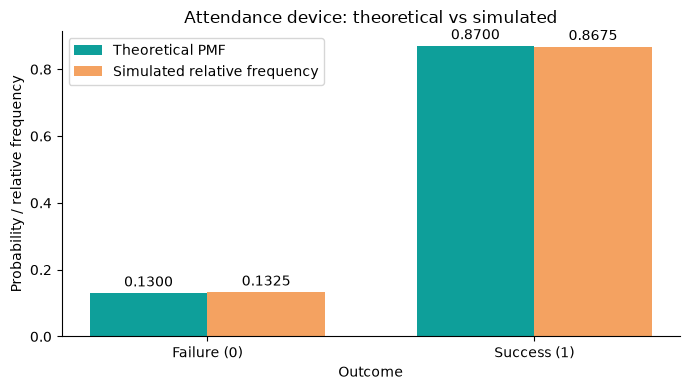

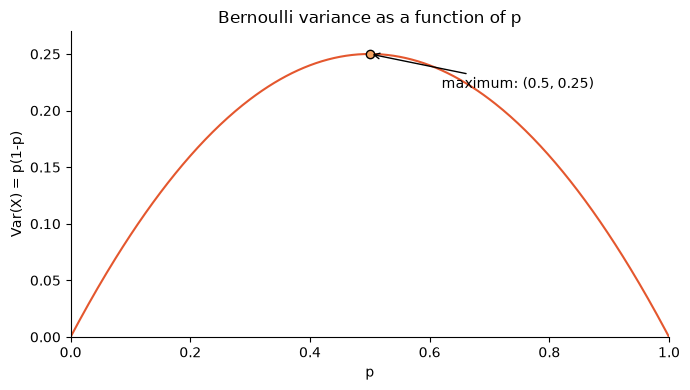

In [12]:
# Q2: estimated Bernoulli model and variance curve
p = 1740 / 2000
n = 2000
rng_seed = 42
simulated = stats.bernoulli.rvs(p, size=n, random_state=rng_seed)
simulated_freq = np.array([(simulated == 0).mean(), (simulated == 1).mean()])
theoretical = stats.bernoulli.pmf([0, 1], p)
print(f"Theoretical p = {p:.4f}")
print(f"Simulated proportion of successes = {simulated.mean():.4f}")

x = np.array([0, 1])
width = 0.36
fig, ax = plt.subplots()
ax.bar(x - width/2, theoretical, width, color=DISCRETE_COLOR, label="Theoretical PMF")
ax.bar(x + width/2, simulated_freq, width, color=HIGHLIGHT_COLOR, label="Simulated relative frequency")
ax.set_xticks(x, ["Failure (0)", "Success (1)"])
ax.set_xlabel("Outcome")
ax.set_ylabel("Probability / relative frequency")
ax.set_title("Attendance device: theoretical vs simulated")
ax.legend()
for xpos, val in zip(x - width/2, theoretical):
    ax.text(xpos, val + 0.02, f"{val:.4f}", ha="center")
for xpos, val in zip(x + width/2, simulated_freq):
    ax.text(xpos, val + 0.02, f"{val:.4f}", ha="center")
plt.tight_layout()
plt.show()

ps = np.linspace(0, 1, 401)
variances = ps * (1 - ps)
fig, ax = plt.subplots()
ax.plot(ps, variances, color=CONTINUOUS_COLOR)
ax.scatter([0.5], [0.25], color=HIGHLIGHT_COLOR, edgecolor="black", zorder=3)
ax.annotate("maximum: (0.5, 0.25)", xy=(0.5, 0.25), xytext=(0.62, 0.22), arrowprops={"arrowstyle": "->"})
ax.set_xlabel("p")
ax.set_ylabel("Var(X) = p(1-p)")
ax.set_title("Bernoulli variance as a function of p")
ax.set_xlim(0, 1)
ax.set_ylim(0, 0.27)
plt.tight_layout()
plt.show()

---
# Part B — Binomial distribution
*Recall:* $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$, $\;E[X]=np$, $\;Var(X)=np(1-p)$.

## Q3. Guessing a multiple-choice quiz &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📝 An online quiz has **12 multiple-choice questions**, each with **4 options** and exactly one correct answer. A student who has not studied guesses every answer at random. Let $X$ = number of questions answered correctly.
>
> **(a)** State $n$ and $p$, check that the **BINS** conditions hold, and compute $P(X=5)$ **by hand**, showing the value of $\binom{12}{5}$.
> **(b)** Find the mean and the variance of $X$.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
>

#### ✍️ Written answer (a) and (b) — *completed*

**(a)** Here \(n=12\) and \(p=1/4=0.25\). The **BINS** conditions hold: there is a fixed number of trials (12), outcomes are binary (correct/incorrect), the trials are treated as independent, and the success probability is constant at 0.25.
\[
P(X=5)=inom{12}{5}(0.25)^5(0.75)^7.
\]
Since \(inom{12}{5}=rac{12!}{5!7!}=792\),
\[
P(X=5)=792(0.25)^5(0.75)^7=0.1032.
\]

**(b)**
\[
E[X]=np=12(0.25)=3.0000,
\qquad Var(X)=np(1-p)=12(0.25)(0.75)=2.2500.
\]


P(X=5) = 0.1032
Mean = 3.0000
Variance = 2.2500


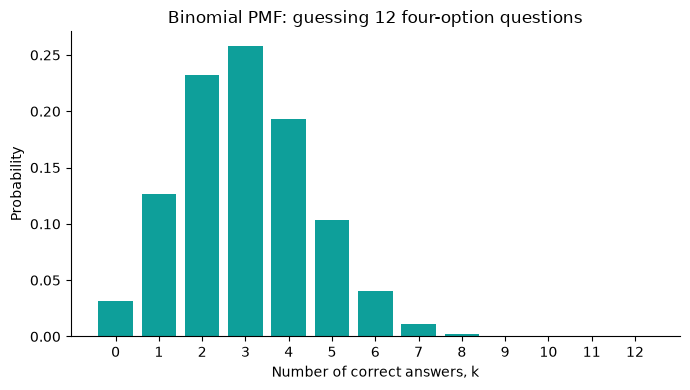

In [13]:
# Q3: Binomial PMF
n, p = 12, 0.25
k = np.arange(0, n + 1)
pmf = stats.binom.pmf(k, n, p)
print(f"P(X=5) = {stats.binom.pmf(5, n, p):.4f}")
print(f"Mean = {stats.binom.mean(n, p):.4f}")
print(f"Variance = {stats.binom.var(n, p):.4f}")

fig, ax = plt.subplots()
ax.bar(k, pmf, color=DISCRETE_COLOR)
ax.set_xlabel("Number of correct answers, k")
ax.set_ylabel("Probability")
ax.set_title("Binomial PMF: guessing 12 four-option questions")
ax.set_xticks(k)
plt.tight_layout()
plt.show()

#### ✍️ Written answer — *Q4 prompt not supplied in the provided notebook*

The uploaded notebook contains an answer placeholder labelled for Q4, but it does not contain the Q4 question or a corresponding code cell. No answer can be determined without that missing prompt.


---
# Part C — Poisson distribution
*Recall:* $P(X=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$, $\;E[X]=Var(X)=\lambda$.

## Q5. Help-desk emails &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📧 The IT help-desk of a college receives on average **3 emails per hour**. Let $X$ = number of emails received in one hour.
>
> **(a)** Compute $P(X = 0)$ and $P(X = 2)$ **by hand**, showing the substitution into the formula ($e^{-3} \approx 0.0498$).
> **(b)** State the mean and the variance, and explain in one line what is special about them for a Poisson distribution.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
> - prints $P(X=0)$, $P(X=2)$ and $P(X \le 5)$,
> - prints the smallest value of $k$ for which $P(X \le k) \ge 0.95$ (use `.ppf` or a loop).

#### ✍️ Written answer (a) and (b) — *completed*

**(a)** For \(\lambda=3\),
\[
P(X=0)=rac{3^0e^{-3}}{0!}=e^{-3}pprox0.0498,
\]
\[
P(X=2)=rac{3^2e^{-3}}{2!}=rac{9(0.0498)}{2}pprox0.2240.
\]

**(b)** The mean and variance are both \(\lambda\):
\[
E[X]=3.0000,\qquad Var(X)=3.0000.
\]
This equality of mean and variance is a special defining property of the Poisson distribution.


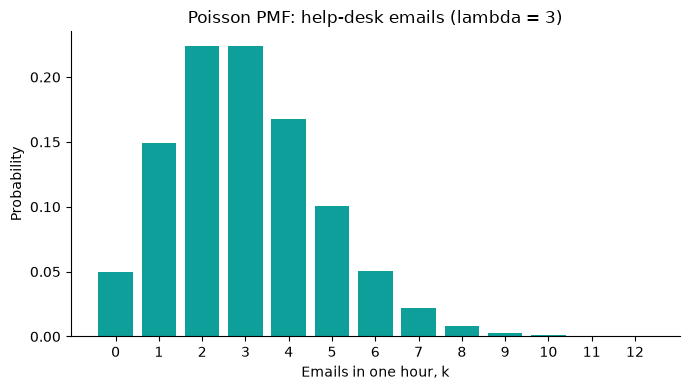

P(X=0) = 0.0498
P(X=2) = 0.2240
P(X<=5) = 0.9161
Smallest k with P(X<=k)>=0.95: 6


In [14]:
# Q5: Poisson PMF for help-desk emails
lam = 3
k = np.arange(0, 13)
pmf = stats.poisson.pmf(k, lam)
fig, ax = plt.subplots()
ax.bar(k, pmf, color=DISCRETE_COLOR)
ax.set_xlabel("Emails in one hour, k")
ax.set_ylabel("Probability")
ax.set_title("Poisson PMF: help-desk emails (lambda = 3)")
ax.set_xticks(k)
plt.tight_layout()
plt.show()

print(f"P(X=0) = {stats.poisson.pmf(0, lam):.4f}")
print(f"P(X=2) = {stats.poisson.pmf(2, lam):.4f}")
print(f"P(X<=5) = {stats.poisson.cdf(5, lam):.4f}")
print(f"Smallest k with P(X<=k)>=0.95: {int(stats.poisson.ppf(0.95, lam))}")

## Q6. Server errors over a night shift &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 🖥️ A web server logs errors at an average rate of **1.5 errors per hour**. The night shift runs from 10 pm to 6 am, i.e. **8 hours**.
>
> **(a)** Find the value of $\lambda$ for the **whole 8-hour shift**, and compute by hand the probability of a **clean shift** (zero errors in the 8 hours).
> **(b)** State the mean and variance for the 8-hour window. The on-call engineer is paged if **more than 18 errors** occur in the shift — write the expression for that probability and name the `scipy` function that gives it directly.
> **(c)** Write Python code that:
> - creates **two subplots side by side** — the PMF for the 1-hour window ($\lambda = 1.5$) and the PMF for the 8-hour window — each with its own sensible range of $k$, title and labels,


#### ✍️ Written answer (a), (b) and (c) — *completed*

**(a)** The rate for the full shift is
\[
\lambda=(1.5	ext{ errors/hour})(8	ext{ hours})=12.
\]
Thus the probability of a clean shift is
\[
P(X=0)=rac{12^0e^{-12}}{0!}=e^{-12}pprox0.0000
\]
(more precisely, \(0.00000614\)).

**(b)** For the 8-hour window,
\[
E[X]=\lambda=12,\qquad Var(X)=\lambda=12.
\]
More than 18 errors means \(P(X>18)\). In SciPy this is given directly by `stats.poisson.sf(18, 12)`.


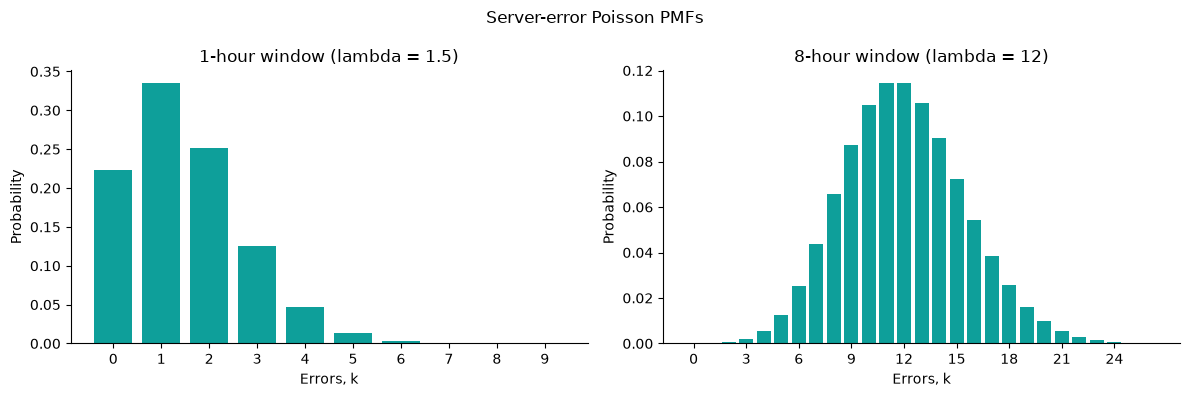

lambda for 8-hour shift = 12.0000
P(clean shift) = 0.0000
P(X>18) = 0.0374


In [15]:
# Q6: Poisson PMFs for one hour and an 8-hour shift
lam_hour = 1.5
lam_shift = 8 * lam_hour
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

k_hour = np.arange(0, 10)
axes[0].bar(k_hour, stats.poisson.pmf(k_hour, lam_hour), color=DISCRETE_COLOR)
axes[0].set_title("1-hour window (lambda = 1.5)")
axes[0].set_xlabel("Errors, k")
axes[0].set_ylabel("Probability")
axes[0].set_xticks(k_hour)

k_shift = np.arange(0, 27)
axes[1].bar(k_shift, stats.poisson.pmf(k_shift, lam_shift), color=DISCRETE_COLOR)
axes[1].set_title("8-hour window (lambda = 12)")
axes[1].set_xlabel("Errors, k")
axes[1].set_ylabel("Probability")
axes[1].set_xticks(np.arange(0, 27, 3))

fig.suptitle("Server-error Poisson PMFs")
plt.tight_layout()
plt.show()
print(f"lambda for 8-hour shift = {lam_shift:.4f}")
print(f"P(clean shift) = {stats.poisson.pmf(0, lam_shift):.4f}")
print(f"P(X>18) = {stats.poisson.sf(18, lam_shift):.4f}")

---
# Part D — Normal distribution
*Recall:* $f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$, $\;Z=\dfrac{X-\mu}{\sigma}$, $\;E[X]=\mu$, $\;Var(X)=\sigma^2$.

## Q7. Battery life of a phone &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🔋 The battery life of a phone model is normally distributed with a mean of **18 hours** and a standard deviation of **1.5 hours**. Let $X$ = battery life of a randomly chosen phone.
>
> **(a)** Compute the **Z-score** for a battery life of 15 hours and say in words what that Z-score means.
> **(b)** Using the 68–95–99.7 rule, state the interval of battery lives that contains about **95%** of the phones. Show how you obtained it.
> **(c)** Write Python code that:
> - generates 400 equally spaced values of $x$ over $\mu \pm 4\sigma$ and computes the PDF,
> - plots the curve in `CONTINUOUS_COLOR` with a title and axis labels,
.

#### ✍️ Written answer (a) and (b) — *completed*

**(a)**
\[
Z=rac{X-\mu}{\sigma}=rac{15-18}{1.5}=-2.0000.
\]
A battery life of 15 hours is 2 standard deviations below the mean.

**(b)** About 95% of observations lie within \(\mu\pm2\sigma\):
\[
18\pm2(1.5)=18\pm3,
\]
so the interval is **[15, 21] hours**.


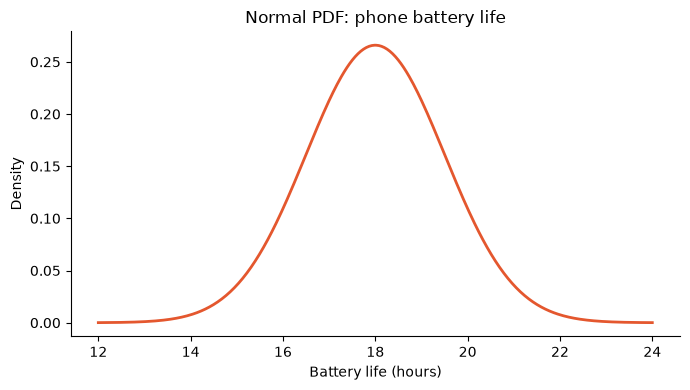

In [16]:
# Q7: Normal PDF for battery life
mu, sigma = 18, 1.5
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
fig, ax = plt.subplots()
ax.plot(x, pdf, color=CONTINUOUS_COLOR, linewidth=2)
ax.set_xlabel("Battery life (hours)")
ax.set_ylabel("Density")
ax.set_title("Normal PDF: phone battery life")
plt.tight_layout()
plt.show()

## Q8. Calibrating a coffee machine &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> ☕ A vending machine fills cups with coffee. The fill volume is normally distributed with a mean of **200 ml**, but the standard deviation is **not known**. The service log shows that **2.5% of cups overflow**, which happens whenever the fill exceeds **210 ml**.
>
> **(a)** Using the standard normal value $z_{0.975} \approx 1.96$, find the standard deviation $\sigma$ of the fill volume. Show the working.
> **(b)** With that $\sigma$, find the volume below which only **1%** of cups fall (the 1st percentile), and state which `scipy` function gives it. A customer complains if the cup holds less than **190 ml** — write the expression for that probability.
> **(c)** Write Python code that:
> - computes $\sigma$ using `stats.norm.ppf` rather than the rounded 1.96,
> - plots the PDF over a sensible range in `CONTINUOUS_COLOR`,



#### ✍️ Written answer (a), (b) and (c) — *completed*

**(a)** Since 2.5% overflow, 97.5% are at or below 210 ml. Therefore,
\[
P(X\le210)=0.975,
\quad rac{210-200}{\sigma}=z_{0.975}pprox1.96.
\]
Hence
\[
\sigma=rac{10}{1.96}pprox5.1020	ext{ ml}.
\]

**(b)** The 1st percentile is found with `stats.norm.ppf(0.01, loc=200, scale=sigma)`. Using the unrounded \(z_{0.975}\) in the code gives approximately **188.1307 ml**. The complaint probability is
\[
P(X<190)=	exttt{stats.norm.cdf(190, loc=200, scale=sigma)}pprox0.0250.
\]


z_0.975 = 1.9600
sigma = 5.1021 ml
1st percentile = 188.1307 ml
P(X<190) = 0.0250


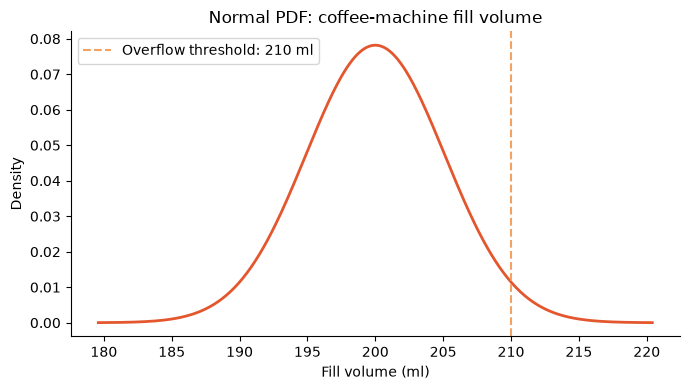

In [17]:
# Q8: Normal PDF for coffee fill volume
mu = 200
z_975 = stats.norm.ppf(0.975)
sigma = (210 - mu) / z_975
percentile_1 = stats.norm.ppf(0.01, loc=mu, scale=sigma)
prob_below_190 = stats.norm.cdf(190, loc=mu, scale=sigma)
print(f"z_0.975 = {z_975:.4f}")
print(f"sigma = {sigma:.4f} ml")
print(f"1st percentile = {percentile_1:.4f} ml")
print(f"P(X<190) = {prob_below_190:.4f}")

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
fig, ax = plt.subplots()
ax.plot(x, pdf, color=CONTINUOUS_COLOR, linewidth=2)
ax.axvline(210, color=HIGHLIGHT_COLOR, linestyle="--", label="Overflow threshold: 210 ml")
ax.set_xlabel("Fill volume (ml)")
ax.set_ylabel("Density")
ax.set_title("Normal PDF: coffee-machine fill volume")
ax.legend()
plt.tight_layout()
plt.show()

---
# Part E — Uniform distribution
*Recall:* $f(x)=\dfrac{1}{b-a}$ for $a \le x \le b$, $\;P(c \le X \le d)=\dfrac{d-c}{b-a}$, $\;E[X]=\dfrac{a+b}{2}$, $\;Var(X)=\dfrac{(b-a)^2}{12}$.

⚠️ **Note on `scipy`:** for a uniform distribution on $[a, b]$ you must use `loc=a` and `scale=b-a`, **not** `loc=a, scale=b`.

## Q9. Waiting for the campus shuttle &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🚌 The campus shuttle leaves the gate exactly every **15 minutes**. A student walks up to the stop at a completely random moment, so her waiting time $X$ is uniformly distributed between **0 and 15 minutes**.
>

> **(a)** Find the mean waiting time and the variance, showing the substitution.
> **(b)** Write Python code that:
> - plots the PDF as a flat line/rectangle over $[0, 15]$ in `CONTINUOUS_COLOR` (extend the x-axis a little beyond the range so the flat top is clear),


#### ✍️ Written answer (a) and (b) — *completed*

**(a)** For \(X\sim Uniform(0,15)\),
\[
E[X]=rac{a+b}{2}=rac{0+15}{2}=7.5000	ext{ minutes},
\]
\[
Var(X)=rac{(b-a)^2}{12}=rac{(15-0)^2}{12}=rac{225}{12}=18.7500	ext{ minutes}^2.
\]

**(b)** The PDF is constant on \([0,15]\), with height
\[
f(x)=rac{1}{b-a}=rac1{15}=0.0667.
\]


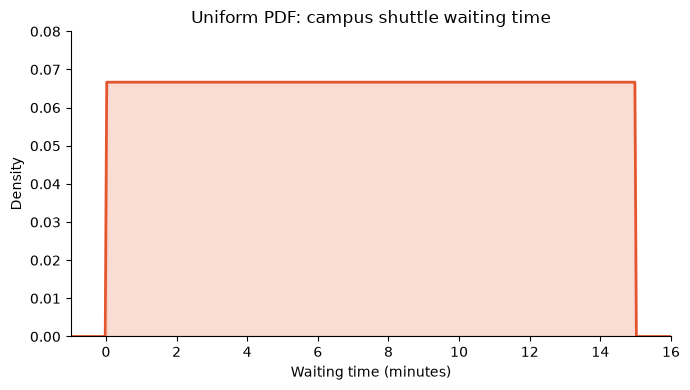

Mean = 7.5000 minutes
Variance = 18.7500 minutes^2


In [18]:
# Q9: Uniform PDF for shuttle waiting time
a, b = 0, 15
x = np.linspace(-1, 16, 400)
pdf = stats.uniform.pdf(x, loc=a, scale=b-a)
fig, ax = plt.subplots()
ax.plot(x, pdf, color=CONTINUOUS_COLOR, linewidth=2)
ax.fill_between(x, pdf, where=(x >= a) & (x <= b), color=CONTINUOUS_COLOR, alpha=0.2)
ax.set_xlabel("Waiting time (minutes)")
ax.set_ylabel("Density")
ax.set_title("Uniform PDF: campus shuttle waiting time")
ax.set_xlim(-1, 16)
ax.set_ylim(0, 0.08)
plt.tight_layout()
plt.show()
print(f"Mean = {stats.uniform.mean(loc=a, scale=b-a):.4f} minutes")
print(f"Variance = {stats.uniform.var(loc=a, scale=b-a):.4f} minutes^2")